# <span style="color:red">  Monthly Data - EBC creation, FMB Quantiles (1970 -2024)

#### Import all our packages and functions

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


In [3]:
import importlib
import src.preference_factors.build_datasets as bd
import src.FamaMacBeth.betas as fmb_betas
import src.FamaMacBeth.pipeline as fmb_pipe
import src.FamaMacBeth.cross_sectional_regression as fmb_csr
import src.FamaMacBeth.pricing as fmb_pricing
import src.FamaMacBeth.backtest as fmb_backtest
import src.FamaMacBeth.plots as fmb_plots

# Reload the modules themselves
importlib.reload(bd)
importlib.reload(fmb_betas)
importlib.reload(fmb_pipe)
importlib.reload(fmb_csr)
importlib.reload(fmb_pricing)
importlib.reload(fmb_backtest)
importlib.reload(fmb_plots)


<module 'src.FamaMacBeth.plots' from '/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/plots.py'>

# <span style="color:red"> Create CSV's for Monthly EBC Weights, Beta Contributions, EBC returns, Preference Returns, Full preference and factors returns (Raw returns) </span>

In [4]:
merged_df, full_merged_df = bd.build_all_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    market_caps_file="sp500_market_caps_monthly.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

# Use raw (non-excess) EBC and CW-EBC spread
ebc = full_merged_df["EBC"]
cw_ebc = full_merged_df["CW"] - full_merged_df["EBC"]

Rolling OLS CAPM:   0%|          | 0/702 [00:00<?, ?it/s]

EBC optimization (parallel):   0%|          | 0/702 [00:00<?, ?it/s]

/Users/evi/Desktop/Invesco_Research_Project/src/preference_factors/build_EBC.py:261: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  weights_rebal = full_weights.resample("Q").last()


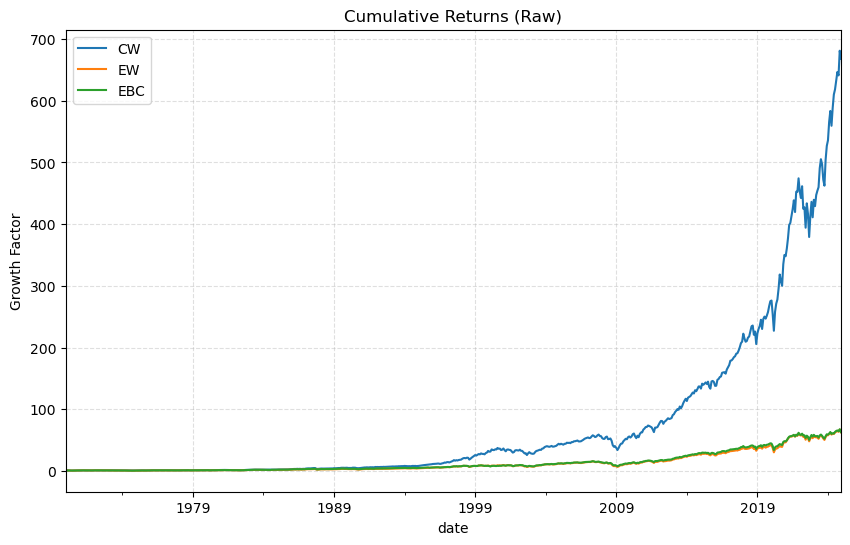

In [5]:
plot_df = full_merged_df[['CW', 'EW', 'EBC']].loc['1970':]
if isinstance(plot_df.index, pd.PeriodIndex):
    plot_df.index = plot_df.index.to_timestamp()
(1 + plot_df).cumprod().plot(figsize=(10, 6))
plt.title("Cumulative Returns (Raw)")
plt.ylabel("Growth Factor")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [6]:
full_merged_df['MKT'] = full_merged_df['MKT_RF'] + full_merged_df['RF']

In [7]:
full_merged_df

,CW,EW,EBC,MKT_RF,SMB,HML,RMW,CMA,RF,MOM,CW-EW,CW-EBC,MKT
date,,,,,,,,,,,,,
1963-07,-0.003284,-0.014061,-0.002700,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101,0.010777,-0.000584,-0.0012
1963-08,0.052482,0.055487,-0.002500,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100,-0.003005,0.054982,0.0533
1963-09,-0.011536,-0.022218,-0.002700,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012,0.010682,-0.008836,-0.0130
1963-10,0.035815,0.023347,-0.002900,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313,0.012468,0.038715,0.0283
1963-11,-0.005499,-0.006967,-0.002700,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078,0.001468,-0.002799,-0.0059
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08,0.023316,0.020143,0.025409,0.0161,-0.0355,-0.0110,0.0076,0.0082,0.0048,0.0481,0.003173,-0.002093,0.0209
2024-09,0.021856,0.019297,0.012079,0.0173,-0.0092,-0.0276,0.0020,-0.0029,0.0040,-0.0062,0.002560,0.009778,0.0213
2024-10,-0.008686,-0.020310,-0.020416,-0.0100,-0.0089,0.0086,-0.0148,0.0098,0.0039,0.0300,0.011624,0.011730,-0.0061


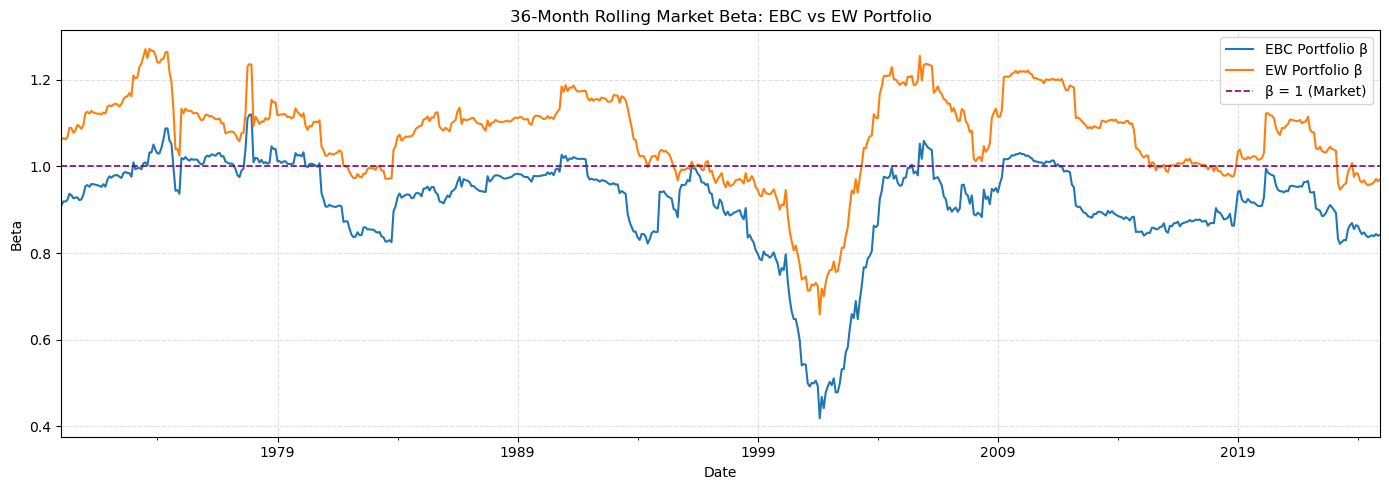


── Rolling Beta Summary ──
         EBC β     EW β
count  660.000  660.000
mean     0.915    1.069
std      0.110    0.104
min      0.419    0.658
25%      0.874    1.003
50%      0.940    1.093
75%      0.982    1.125
max      1.119    1.271


In [8]:
import statsmodels.api as sm

# ── Rolling 36-month Market Beta: EBC vs EW ──
window = 36

ebc_ret = full_merged_df["EBC"].copy()
ew_ret  = full_merged_df["EW"].copy()
mkt     = full_merged_df["MKT"].copy()

# Normalize indices to DatetimeIndex for alignment + plotting
if isinstance(ebc_ret.index, pd.PeriodIndex):
    ebc_ret.index = ebc_ret.index.to_timestamp()
    ew_ret.index  = ew_ret.index.to_timestamp()
if isinstance(mkt.index, pd.PeriodIndex):
    mkt.index = mkt.index.to_timestamp()

combined = pd.DataFrame({
    "EBC": ebc_ret,
    "EW":  ew_ret,
    "MKT": mkt
}).dropna()

beta_ebc, beta_ew, dates = [], [], []

for i in range(window, len(combined) + 1):
    w  = combined.iloc[i - window:i]
    X  = sm.add_constant(w["MKT"])
    try:
        beta_ebc.append(sm.OLS(w["EBC"], X).fit().params["MKT"])
        beta_ew.append( sm.OLS(w["EW"],  X).fit().params["MKT"])
    except Exception:
        beta_ebc.append(np.nan)
        beta_ew.append(np.nan)
    dates.append(combined.index[i - 1])

beta_df = pd.DataFrame({"EBC β": beta_ebc, "EW β": beta_ew}, index=dates)

plot_beta = beta_df.loc['1970':]

plt.figure(figsize=(14, 5))
plot_beta["EBC β"].plot(linewidth=1.5, label="EBC Portfolio β", color="tab:blue")
plot_beta["EW β"].plot( linewidth=1.5, label="EW Portfolio β",  color="tab:orange")
plt.axhline(1.0, color="purple", linestyle="--", linewidth=1.2, label="β = 1 (Market)")
plt.title("36-Month Rolling Market Beta: EBC vs EW Portfolio")
plt.ylabel("Beta")
plt.xlabel("Date")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("\n── Rolling Beta Summary ──")
print(plot_beta.describe().round(3))

Correlation (EBC vs EW)       : 0.987069
Mean monthly return difference       : -0.0308%  (-0.37% annualized)
Std of monthly return difference     : 1.0082%
Max monthly divergence               : 4.7530%
EBC annualized mean return    : 8.7534%
EW  annualized mean return    : 9.1235%


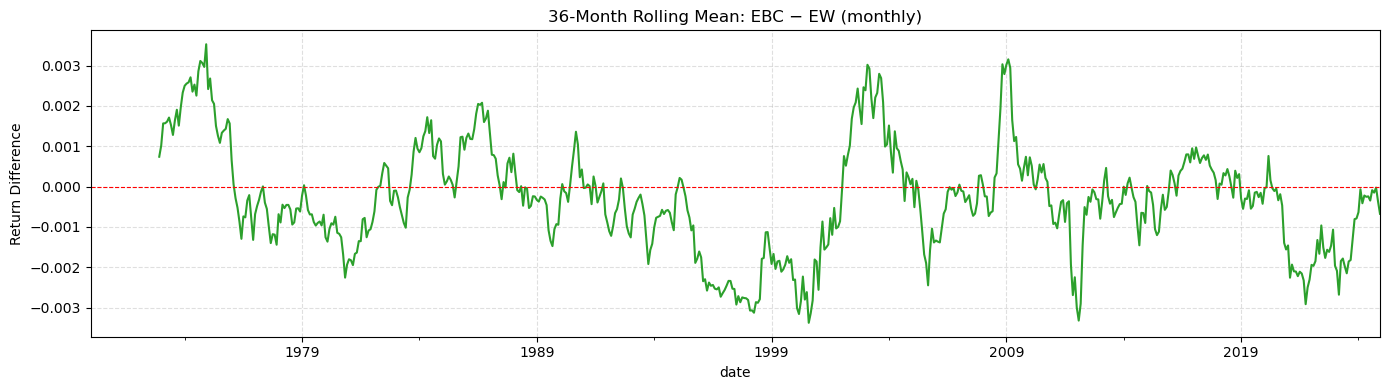

In [9]:
# ── EBC vs EW: are they actually the same portfolio? ──
comp = pd.DataFrame({
    "EBC": full_merged_df["EBC"],
    "EW":  full_merged_df["EW"]
})

comp = comp['1970':]
if isinstance(comp.index, pd.PeriodIndex):
    comp.index = comp.index.to_timestamp()
comp = comp.dropna()

corr = comp["EBC"].corr(comp["EW"])
diff = (comp["EBC"] - comp["EW"])

print(f"Correlation (EBC vs EW)       : {corr:.6f}")
print(f"Mean monthly return difference       : {diff.mean()*100:.4f}%  ({diff.mean()*1200:.2f}% annualized)")
print(f"Std of monthly return difference     : {diff.std()*100:.4f}%")
print(f"Max monthly divergence               : {diff.abs().max()*100:.4f}%")
print(f"EBC annualized mean return    : {comp['EBC'].mean()*12:.4%}")
print(f"EW  annualized mean return    : {comp['EW'].mean()*12:.4%}")

# Plot the return difference over time (full sample)
diff.rolling(36).mean().plot(figsize=(14,4), linewidth=1.5, color="tab:green")
plt.axhline(0, color="red", linestyle="--", linewidth=0.8)
plt.title("36-Month Rolling Mean: EBC − EW (monthly)")
plt.ylabel("Return Difference")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

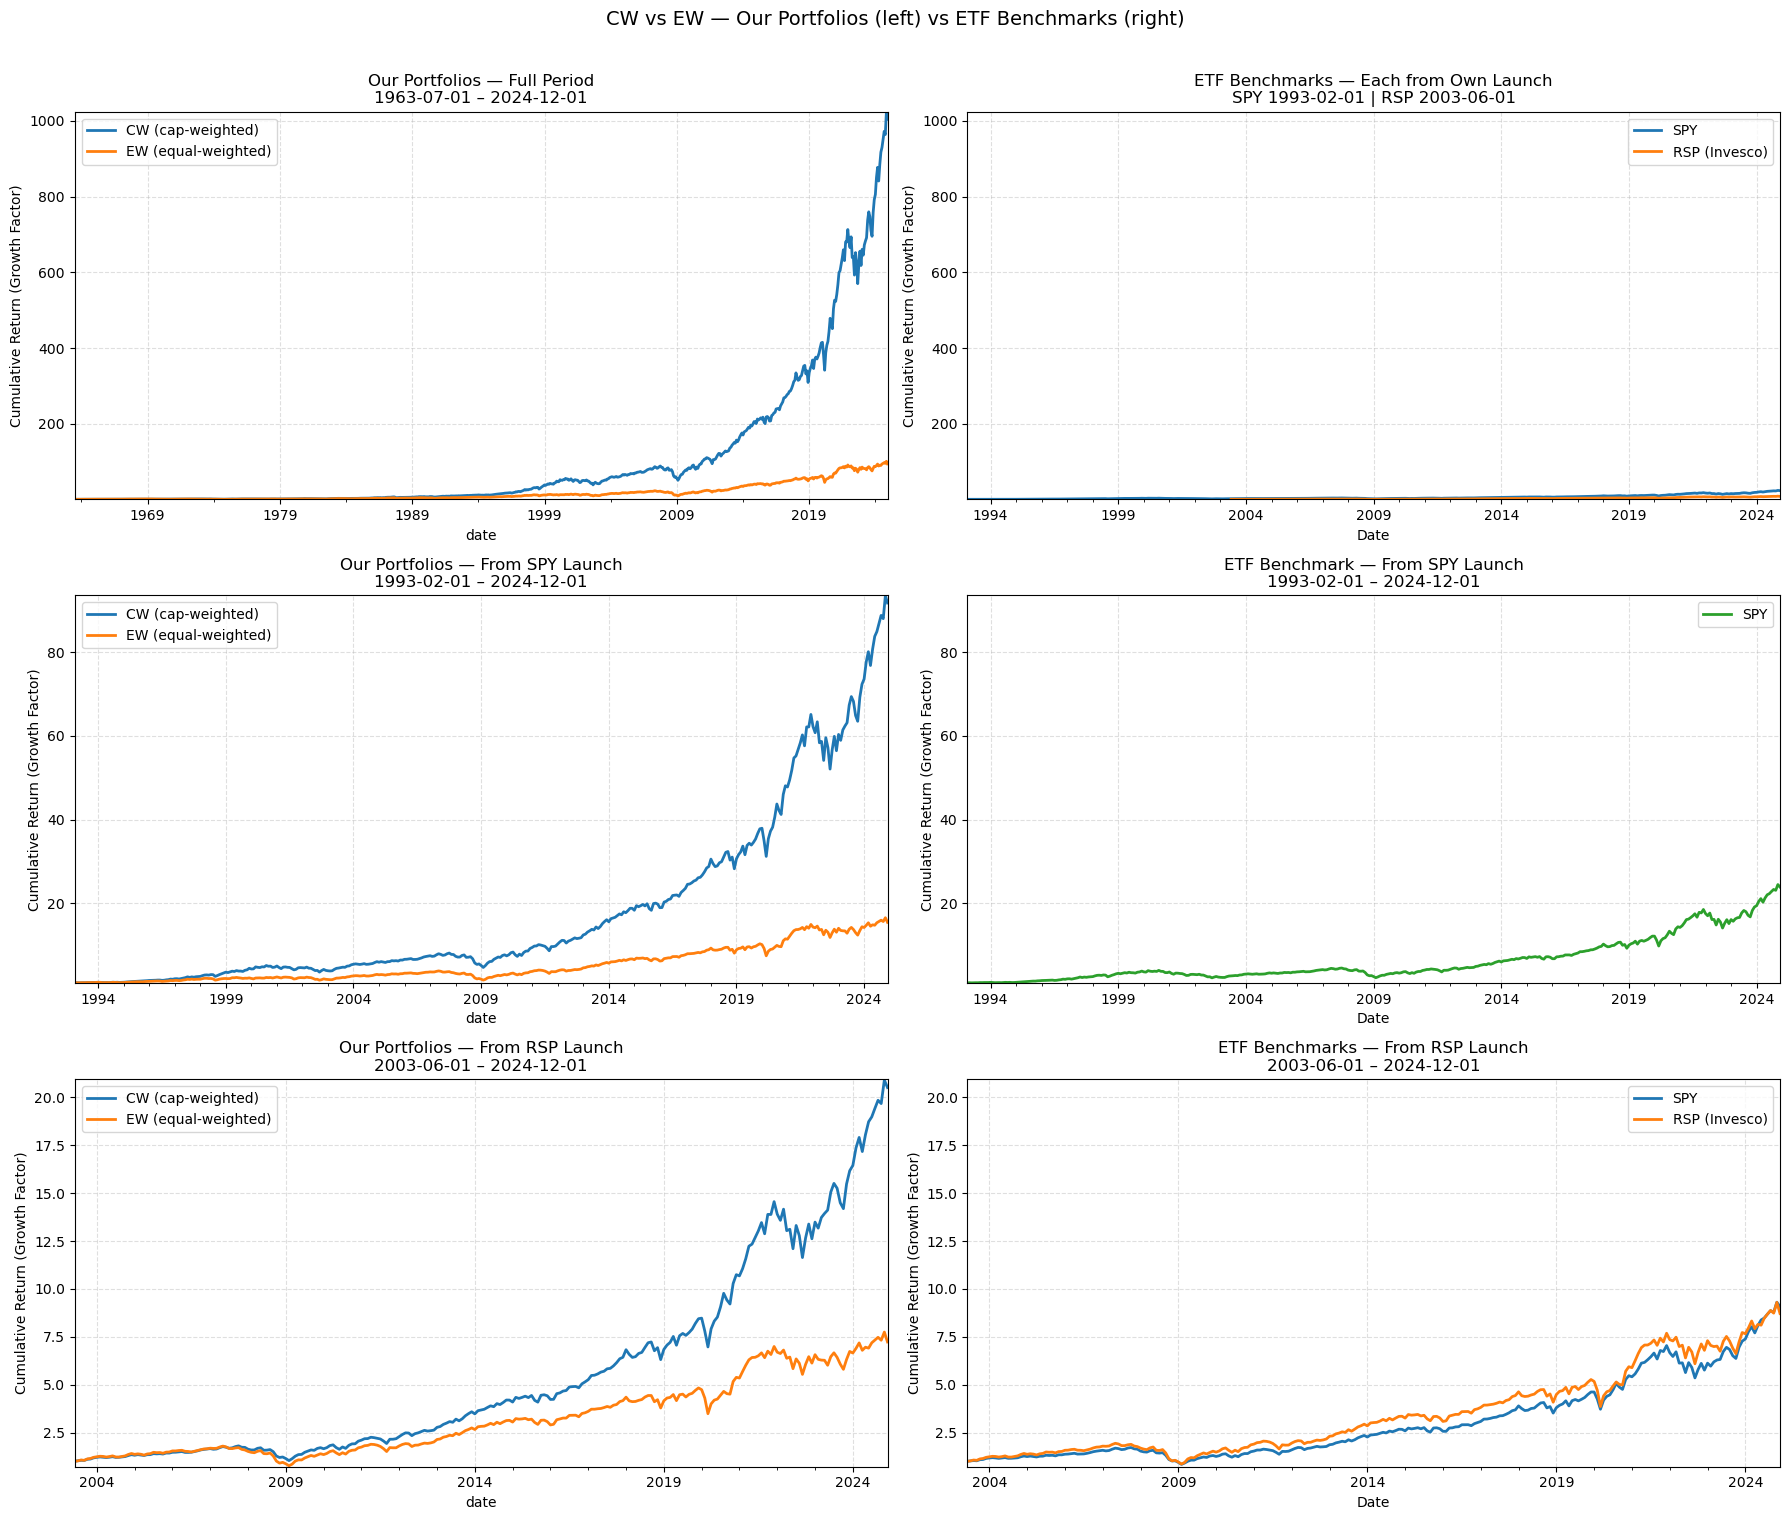


── Annualized Mean Return (raw) ──
  CW (ours, full)  : 12.41%
  EW (ours, full)  : 8.92%
  CW (ours, 1993+) : 15.32%
  EW (ours, 1993+) : 10.03%
  SPY  (1993+)     : 11.09%
  CW (ours, 2003+) : 15.11%
  EW (ours, 2003+) : 10.66%
  SPY  (2003+)     : 11.34%
  RSP  (2003+)     : 11.50%


In [10]:
import yfinance as yf

# ── Download ETF data ──
spy_prices = yf.download("SPY", start="1993-01-01", end="2025-01-01", progress=False, auto_adjust=True)["Close"].squeeze()
rsp_prices = yf.download("RSP", start="2003-01-01", end="2025-01-01", progress=False, auto_adjust=True)["Close"].squeeze()

spy_ret = spy_prices.resample("ME").last().pct_change().dropna()
rsp_ret = rsp_prices.resample("ME").last().pct_change().dropna()
spy_ret.index = spy_ret.index.to_period("M").to_timestamp(how="start")
rsp_ret.index = rsp_ret.index.to_period("M").to_timestamp(how="start")

# ── Our raw portfolios ──
our_data = full_merged_df[["CW", "EW"]].copy()
if isinstance(our_data.index, pd.PeriodIndex):
    our_data.index = our_data.index.to_timestamp(how="start")

spy_start = spy_ret.index.min()   # ~Jan 1993
rsp_start = rsp_ret.index.min()   # ~Apr 2003

# ── Helper: compute geometric cumulative returns ──
def cum_geo(df):
    return (1 + df).cumprod()

# ── 3 rows × 2 cols: left = our portfolios, right = ETFs, same y-scale per row ──
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# ── Row 1: Full period ──
ours_full = cum_geo(our_data)
etf_full  = pd.concat([
    cum_geo(spy_ret).rename("SPY"),
    cum_geo(rsp_ret).rename("RSP (Invesco)")
], axis=1)

ours_full.plot(ax=axes[0, 0], linewidth=2)
axes[0, 0].set_title(f"Our Portfolios — Full Period\n{our_data.index.min().date()} – {our_data.index.max().date()}")
axes[0, 0].set_ylabel("Cumulative Return (Growth Factor)")
axes[0, 0].legend(["CW (cap-weighted)", "EW (equal-weighted)"])
axes[0, 0].grid(True, linestyle="--", alpha=0.4)

etf_full.plot(ax=axes[0, 1], linewidth=2)
axes[0, 1].set_title(f"ETF Benchmarks — Each from Own Launch\nSPY {spy_start.date()} | RSP {rsp_start.date()}")
axes[0, 1].set_ylabel("Cumulative Return (Growth Factor)")
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle="--", alpha=0.4)

ymin1 = min(ours_full.min().min(), etf_full.min().min())
ymax1 = max(ours_full.max().max(), etf_full.max().max())
for ax in axes[0]:
    ax.set_ylim(ymin1 - 0.05, ymax1 + 0.05)

# ── Row 2: From SPY launch (~1993) ──
ours_spy = cum_geo(our_data.loc[spy_start:])
etf_spy  = cum_geo(spy_ret.loc[spy_start:]).rename("SPY")

ours_spy.plot(ax=axes[1, 0], linewidth=2)
axes[1, 0].set_title(f"Our Portfolios — From SPY Launch\n{spy_start.date()} – {our_data.index.max().date()}")
axes[1, 0].set_ylabel("Cumulative Return (Growth Factor)")
axes[1, 0].legend(["CW (cap-weighted)", "EW (equal-weighted)"])
axes[1, 0].grid(True, linestyle="--", alpha=0.4)

etf_spy.plot(ax=axes[1, 1], linewidth=2, color="tab:green")
axes[1, 1].set_title(f"ETF Benchmark — From SPY Launch\n{spy_start.date()} – {spy_ret.index.max().date()}")
axes[1, 1].set_ylabel("Cumulative Return (Growth Factor)")
axes[1, 1].legend(["SPY"])
axes[1, 1].grid(True, linestyle="--", alpha=0.4)

ymin2 = min(ours_spy.min().min(), etf_spy.min())
ymax2 = max(ours_spy.max().max(), etf_spy.max())
for ax in axes[1]:
    ax.set_ylim(ymin2 - 0.05, ymax2 + 0.05)

# ── Row 3: From RSP launch (~2003) ──
ours_rsp = cum_geo(our_data.loc[rsp_start:])
etf_rsp  = pd.concat([
    cum_geo(spy_ret.loc[rsp_start:]).rename("SPY"),
    cum_geo(rsp_ret.loc[rsp_start:]).rename("RSP (Invesco)")
], axis=1)

ours_rsp.plot(ax=axes[2, 0], linewidth=2)
axes[2, 0].set_title(f"Our Portfolios — From RSP Launch\n{rsp_start.date()} – {our_data.index.max().date()}")
axes[2, 0].set_ylabel("Cumulative Return (Growth Factor)")
axes[2, 0].legend(["CW (cap-weighted)", "EW (equal-weighted)"])
axes[2, 0].grid(True, linestyle="--", alpha=0.4)

etf_rsp.plot(ax=axes[2, 1], linewidth=2)
axes[2, 1].set_title(f"ETF Benchmarks — From RSP Launch\n{rsp_start.date()} – {rsp_ret.index.max().date()}")
axes[2, 1].set_ylabel("Cumulative Return (Growth Factor)")
axes[2, 1].legend()
axes[2, 1].grid(True, linestyle="--", alpha=0.4)

ymin3 = min(ours_rsp.min().min(), etf_rsp.min().min())
ymax3 = max(ours_rsp.max().max(), etf_rsp.max().max())
for ax in axes[2]:
    ax.set_ylim(ymin3 - 0.05, ymax3 + 0.05)

plt.suptitle("CW vs EW — Our Portfolios (left) vs ETF Benchmarks (right)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary stats ──
print("\n── Annualized Mean Return (raw) ──")
print(f"  CW (ours, full)  : {our_data['CW'].mean()*12:.2%}")
print(f"  EW (ours, full)  : {our_data['EW'].mean()*12:.2%}")
print(f"  CW (ours, 1993+) : {our_data.loc[spy_start:,'CW'].mean()*12:.2%}")
print(f"  EW (ours, 1993+) : {our_data.loc[spy_start:,'EW'].mean()*12:.2%}")
print(f"  SPY  (1993+)     : {spy_ret.mean()*12:.2%}")
print(f"  CW (ours, 2003+) : {our_data.loc[rsp_start:,'CW'].mean()*12:.2%}")
print(f"  EW (ours, 2003+) : {our_data.loc[rsp_start:,'EW'].mean()*12:.2%}")
print(f"  SPY  (2003+)     : {spy_ret.loc[rsp_start:].mean()*12:.2%}")
print(f"  RSP  (2003+)     : {rsp_ret.mean()*12:.2%}")

# <span style="color:red"> Get rolling betas for the two focus portfolios EBC and CW - EBC </span>

#### create factor returns

In [11]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")

# Convert to timestamp to match asset_returns index
ebc.index = ebc.index.to_timestamp()
cw_ebc.index = cw_ebc.index.to_timestamp()

factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()

#### get asset returns (raw, no RF subtraction)

In [12]:
asset_returns, caps_df, ff_factors = fmb_pipe.load_monthly_inputs(DATA_RAW_DIR, excess= False)

#### compute rolling betas for EBc and CW-EBC

In [13]:
betas_ebc = fmb_betas.compute_rolling_betas(asset_returns, ebc, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 702/702 [00:04<00:00, 160.69it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:72: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)


In [14]:

betas_cw_ebc = fmb_betas.compute_rolling_betas(asset_returns, cw_ebc, rolling_window=36, min_obs=10)

Estimating rolling betas: 100%|██████████| 702/702 [00:05<00:00, 126.12it/s]
/Users/evi/Desktop/Invesco_Research_Project/src/FamaMacBeth/betas.py:72: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked = betas_df.stack(dropna=True)


=== Beta Coverage ===
EBC betas   : (702, 1955)  |  date range: 1966-07-01 → 2024-12-01
CW-EBC betas: (702, 1955)  |  date range: 1966-07-01 → 2024-12-01

=== Average non-NaN assets per period (first 5 / last 5) ===
EBC betas:
date
1966-07-01    437
1966-08-01    436
1966-09-01    439
1966-10-01    439
1966-11-01    435
2024-08-01    445
2024-09-01    447
2024-10-01    445
2024-11-01    444
2024-12-01    445
CW-EBC betas:
date
1966-07-01    437
1966-08-01    436
1966-09-01    439
1966-10-01    439
1966-11-01    435
2024-08-01    445
2024-09-01    447
2024-10-01    445
2024-11-01    444
2024-12-01    445

=== Cross-sectional distribution (all dates stacked) ===
          EBC beta  CW-EBC beta
count  296107.0000  296107.0000
mean        1.3546      -0.3316
std         2.6563       1.9091
min        -0.0987      -7.2210
25%         0.7634      -1.3547
50%         1.0772      -0.3032
75%         1.4167       0.8048
max        32.7257       5.2376

=== Extreme EBC beta values (post-1970 onl

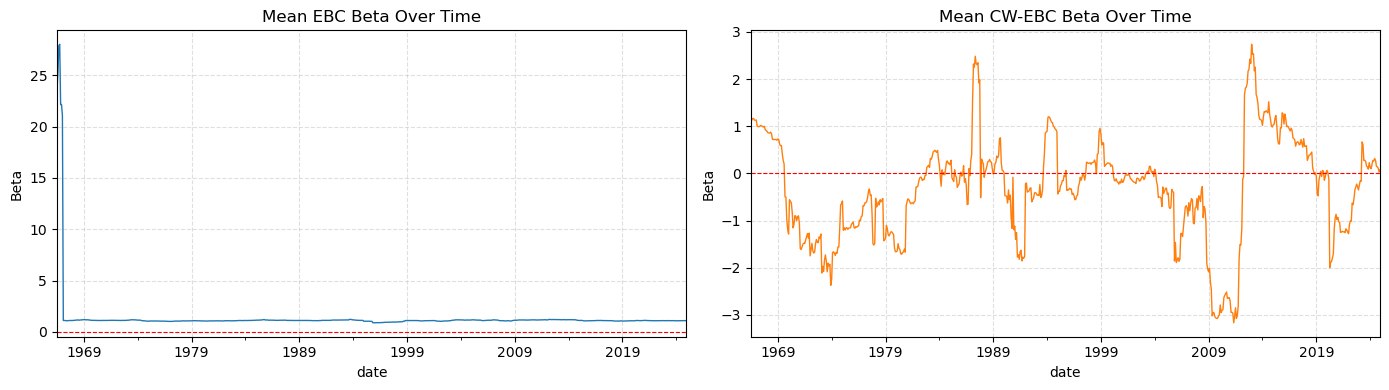

In [15]:
# ── Basic beta sanity checks ──

print("=== Beta Coverage ===")
print(f"EBC betas   : {betas_ebc.shape}  |  date range: {betas_ebc.index.min().date()} → {betas_ebc.index.max().date()}")
print(f"CW-EBC betas: {betas_cw_ebc.shape}  |  date range: {betas_cw_ebc.index.min().date()} → {betas_cw_ebc.index.max().date()}")

print("\n=== Average non-NaN assets per period (first 5 / last 5) ===")
ebc_coverage   = betas_ebc.notna().sum(axis=1)
cwebc_coverage = betas_cw_ebc.notna().sum(axis=1)
print("EBC betas:")
print(pd.concat([ebc_coverage.head(), ebc_coverage.tail()]).to_string())
print("CW-EBC betas:")
print(pd.concat([cwebc_coverage.head(), cwebc_coverage.tail()]).to_string())

print("\n=== Cross-sectional distribution (all dates stacked) ===")
ebc_flat   = betas_ebc.stack(future_stack=True).dropna()
cwebc_flat = betas_cw_ebc.stack(future_stack=True).dropna()
print(pd.DataFrame({
    "EBC beta": ebc_flat.describe(),
    "CW-EBC beta": cwebc_flat.describe()
}).round(4))

print("\n=== Extreme EBC beta values (post-1970 only) ===")
ebc_post70 = betas_ebc.loc["1970-01":].stack(future_stack=True).dropna()
print(ebc_post70.quantile([0.99, 0.995, 0.999]).round(4))

print("\n=== Cross-correlation between mean EBC beta and mean CW-EBC beta (should be low) ===")
mean_betas = pd.DataFrame({
    "mean_EBC": betas_ebc.mean(axis=1),
    "mean_CW_EBC": betas_cw_ebc.mean(axis=1)
}).dropna()
print(mean_betas.corr().round(3))

# ── Time-series plot of cross-sectional mean betas ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mean_betas["mean_EBC"].plot(ax=axes[0], linewidth=1)
axes[0].set_title("Mean EBC Beta Over Time")
axes[0].set_ylabel("Beta")
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0].grid(True, linestyle="--", alpha=0.4)

mean_betas["mean_CW_EBC"].plot(ax=axes[1], linewidth=1, color="tab:orange")
axes[1].set_title("Mean CW-EBC Beta Over Time")
axes[1].set_ylabel("Beta")
axes[1].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# <span style="color:red"> Cap Weighted Portfolio Plots --> Run full factor pipeline --> Two factor regressions FMB </span>

In [16]:
start_date = "1969-10-01"

## Filter all returns to match start date

In [17]:
asset_returns_trimmed = asset_returns.loc[start_date:]
caps_df_trimmed = caps_df.loc[start_date:]
factor_returns_trimmed = factor_returns.loc[start_date:]
betas_ebc_trimmed = betas_ebc.loc[start_date:]
betas_cw_ebc_trimmed = betas_cw_ebc.loc[start_date:]

In [18]:
n_q1, n_q2 = 1,10

In [19]:
cw_results = fmb_pipe.run_full_factor_pipeline(
    beta_EBC_df = betas_ebc_trimmed,
    beta_CW_EBC_df=betas_cw_ebc_trimmed,
    returns_df=asset_returns_trimmed,
    caps_df = caps_df_trimmed,
    EBC_returns_df=factor_returns_trimmed["EBC"],
    Cap_EBC_returns_df=factor_returns_trimmed["CW-EBC"],
    cap_weights=True,
    n_q1 = n_q1,
    n_q2 = n_q2,
    frequency = 'monthly',
    formation_frequency='quarterly',
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC"
)

cw_results["mean_grid"]*12

forming portfolios (quarterly): 100%|██████████| 221/221 [00:03<00:00, 57.33it/s]


,1,2,3,4,5,6,7,8,9,10
1,0.168195,0.150977,0.150503,0.159309,0.15984,0.175763,0.173881,0.186964,0.211453,0.232589


In [20]:
cw_results['portrets_wide']

,Q1_Q1,Q1_Q2,Q1_Q3,Q1_Q4,Q1_Q5,Q1_Q6,Q1_Q7,Q1_Q8,Q1_Q9,Q1_Q10
date,,,,,,,,,,
1970-01-01,-0.077298,-0.088000,-0.044311,-0.088574,-0.056067,-0.041554,-0.045656,-0.043856,-0.055385,-0.057397
1970-02-01,0.031620,0.054343,0.090148,0.095037,0.086386,0.098195,0.097495,0.087909,0.083162,0.127598
1970-03-01,-0.012036,0.026548,0.012385,0.007447,-0.003590,0.031778,0.013890,0.015029,0.012558,0.008340
1970-04-01,-0.094694,-0.073323,-0.095852,-0.068187,-0.092262,-0.086148,-0.098137,-0.075946,-0.101196,-0.074748
1970-05-01,-0.077878,-0.014028,-0.052890,-0.032163,-0.044099,-0.045049,-0.066110,-0.062993,-0.060588,-0.040982
...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.002721,0.061763,0.035674,0.061683,0.020893,0.040782,0.042782,0.030296,0.040365,0.025245
2024-09-01,0.037420,-0.003091,0.017250,0.030975,0.013020,0.004420,0.025346,0.015693,0.001253,0.007960
2024-10-01,-0.003221,-0.015006,-0.026793,0.012435,-0.019986,0.021354,-0.012911,-0.025304,0.007649,-0.018871


In [21]:
#1,3
rename_map =  {
    "Q1_Q1": "High Pref",
    "Q1_Q2": "Mid Pref",
    "Q1_Q3": "Low Pref"
}
# Save pre-rename copy for true geometric mean computation (needs Q1_Q1 style column names)
cw_portrets_raw = cw_results['portrets_wide'].copy()
cw_results['portrets_wide'] = cw_results['portrets_wide'].rename(columns=rename_map)

In [22]:
full_merged_df.index = full_merged_df.index.to_timestamp(how="start")

In [23]:
cw_results['portrets_wide'].columns

Index(['High Pref', 'Mid Pref', 'Low Pref', 'Q1_Q4', 'Q1_Q5', 'Q1_Q6', 'Q1_Q7',
       'Q1_Q8', 'Q1_Q9', 'Q1_Q10'],
      dtype='object')

In [28]:
cw_complete_df = full_merged_df.join(
    cw_results['portrets_wide'],
    how="inner"
)

selected_columns = ["CW","High Pref","Mid Pref","Low Pref"]

In [25]:
#selected_columns = ['CW','Q1_Q1', 'Q1_Q2', 'Q1_Q3', 'Q1_Q4', 'Q1_Q5', 'Q1_Q6', 'Q1_Q7', 'Q1_Q8','Q1_Q9', 'Q1_Q10']

In [29]:
cw_complete_df = full_merged_df.join(
    cw_results['portrets_wide'],
    how="inner"
)

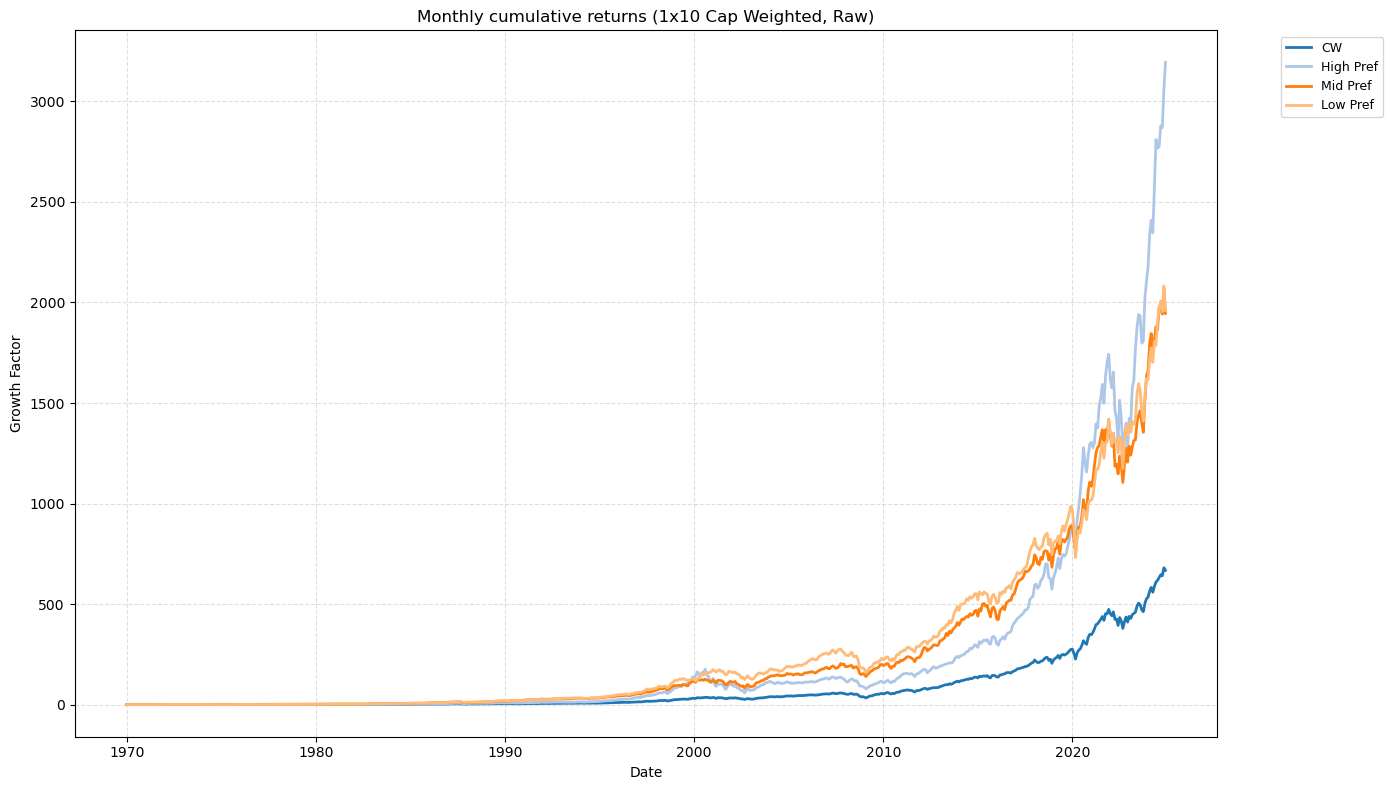

In [30]:
fmb_plots.plot_cum_returns(cw_complete_df[selected_columns], title=f"Monthly cumulative returns ({n_q1}x{n_q2} Cap Weighted, Raw)", log=False)

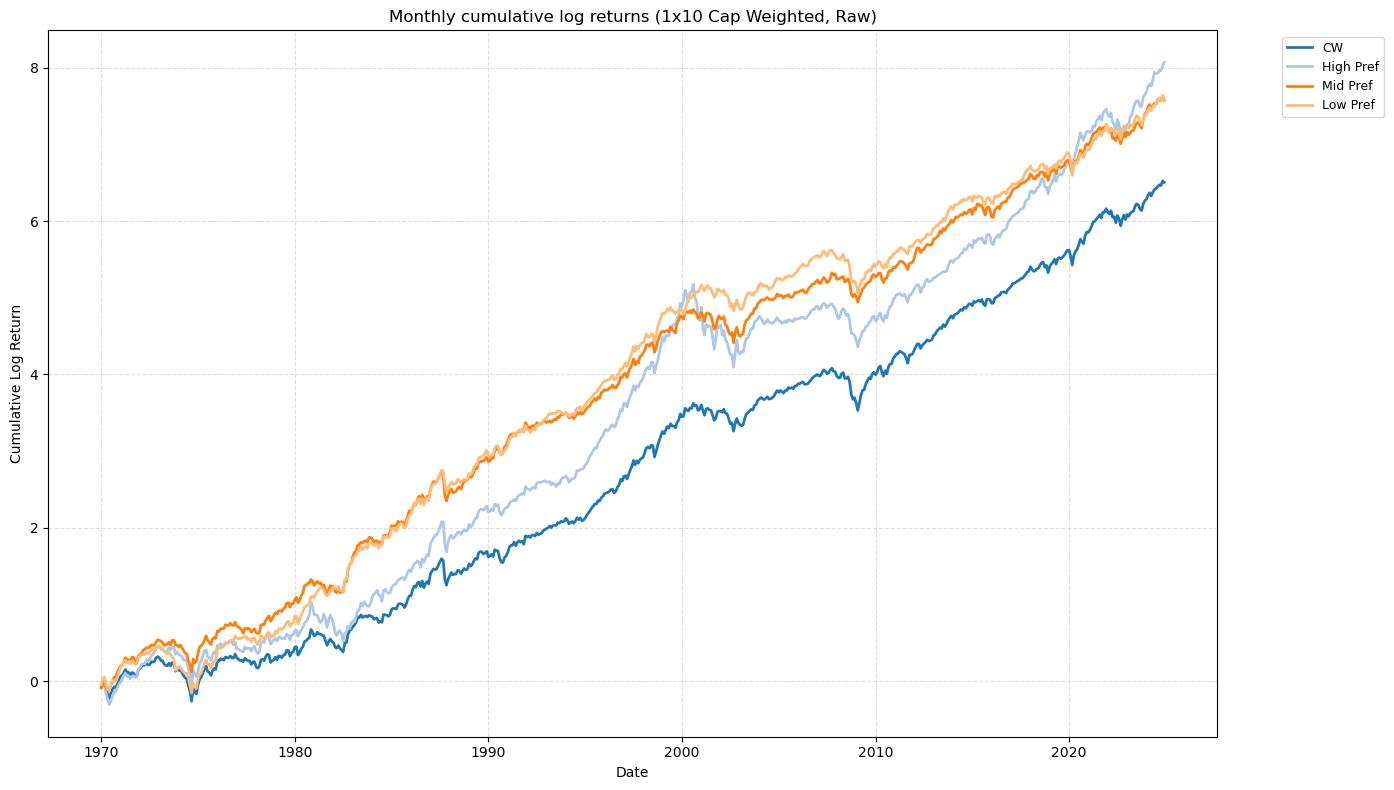

In [31]:
fmb_plots.plot_cum_returns(cw_complete_df[selected_columns], title = f"Monthly cumulative log returns ({n_q1}x{n_q2} Cap Weighted, Raw)", log = True)

In [32]:
period = start_date[:4] + '_2024'
save_dir = DATA_PROCESSED_DIR / 'monthly'

In [33]:
monthly_cw_quantile_returns = cw_complete_df[selected_columns]
monthly_cw_quantile_returns.to_csv(save_dir / f"monthly_{period}_cw_quantile_returns_{n_q1}x{n_q2}.csv")

In [34]:
# Arithmetic mean grid (annualized as mean × 12)
#fmb_plots.plot_mean_grid_new(cw_results["mean_grid"], annualize=True, cw=True, geometric=False)

In [35]:
cw_results["mean_grid"]

,1,2,3,4,5,6,7,8,9,10
1,0.014016,0.012581,0.012542,0.013276,0.01332,0.014647,0.01449,0.01558,0.017621,0.019382


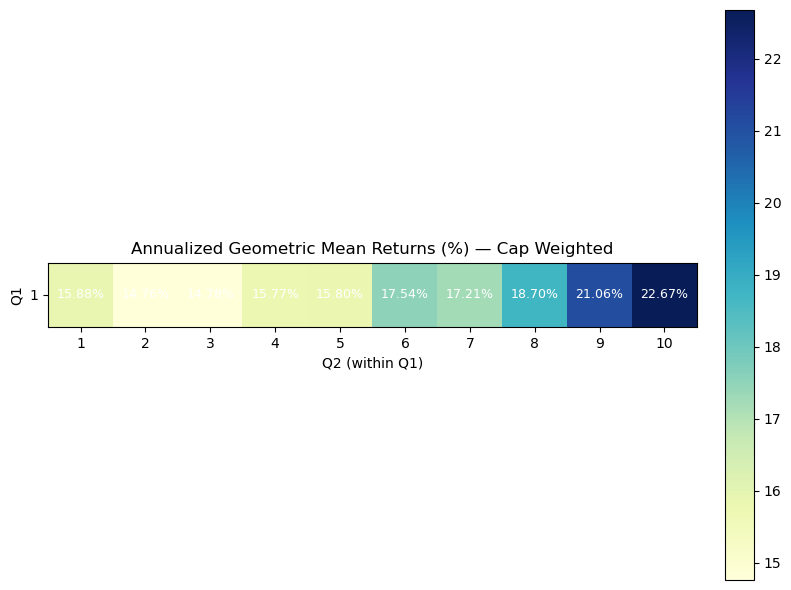

In [36]:
# True geometric mean grid (annualized as (1+geo_monthly)^12 − 1)
cw_actual_mean_grid = fmb_plots.plot_mean_grid_new(
    cw_results["mean_grid"], annualize=True, cw=True, geometric=True,
    portrets_wide=cw_portrets_raw
)

In [37]:
# ── Benchmark: annualized geometric mean returns over the analysis period ──
cw_geo = np.expm1(np.log1p(cw_complete_df['CW']).mean())
cw_ann = (1 + cw_geo) ** 12 - 1
print(f"Annualized Geometric Mean Return ({start_date[:4]}–2024)")
print(f"  CW (ours) : {cw_ann:.2%}")
try:
    spy_geo = np.expm1(np.log1p(spy_ret.loc[start_date:]).mean())
    spy_ann = (1 + spy_geo) ** 12 - 1
    print(f"  SPY       : {spy_ann:.2%}")
except Exception:
    print("  SPY       : (run ETF cell first)")

Annualized Geometric Mean Return (1969–2024)
  CW (ours) : 12.55%
  SPY       : 10.45%


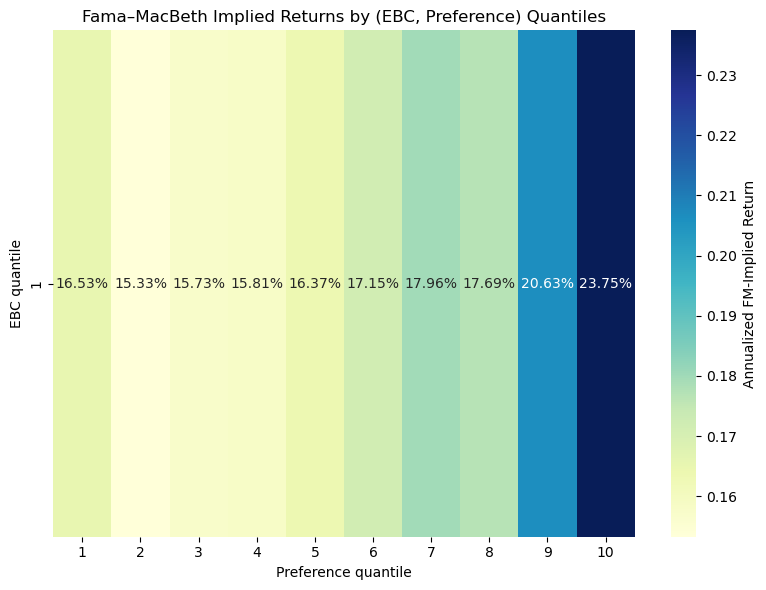

In [38]:
cw_implied_mean_grid = fmb_plots.plot_expected_return_grid(cw_results["pricing"], cw_results["fm_table"], n_q1, n_q2)

## turnover

In [39]:
# ── Portfolio Turnover (Cap Weighted) ─────────────────────────────────────
# Turnover = % of stocks that left each cell at each quarterly rebalancing.
# Stock membership is determined by beta sorts (identical for CW and EW).

members_cw = cw_results["members"].copy()
m = members_cw.reset_index()

# Identify the rebalancing date = first trading date of each quarter
m['period'] = m['date'].dt.to_period('Q')
first_date_per_period = m.groupby('period')['date'].min()
m_first = m[m['date'].isin(first_date_per_period.values)]

portfolio_names = {
    (1,1): "High Preference",
    (1,2): "Mid Preference",
    (1,3): "Low Preference"
    
}

In [41]:
members_cw

q1  q2
date       ticker        
1970-01-01 A        1  10
           AA       1   4
           ABA      1  10
           ABT      1   2
           ABW      1   9
...                ..  ..
2024-12-01 XYL      1   3
           YUM      1   7
           ZBH      1   9
           ZBRA     1   2
           ZTS      1   3

[278457 rows x 2 columns]

In [42]:
turnover_dict_cw = {}

for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        cell_data = m_first[(m_first['q1'] == q1) & (m_first['q2'] == q2)]
        by_period = cell_data.groupby('period')['ticker'].apply(set)

        turnovers, dates_out = [], []
        prev_set = None
        for period_key, tickers in by_period.items():
            if prev_set is not None:
                left = prev_set - tickers
                turnovers.append(len(left) / len(prev_set) if prev_set else np.nan)
                dates_out.append(period_key.to_timestamp())
            prev_set = tickers

        turnover_dict_cw[portfolio_names[(q1, q2)]] = pd.Series(turnovers, index=dates_out)

turnover_cw = pd.DataFrame(turnover_dict_cw)

# ── Plot: 3x3 grid ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharey=True)
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, turnover_cw.columns):
    avg = turnover_cw[col].mean()
    ax.plot(turnover_cw.index, turnover_cw[col], color='steelblue', linewidth=1, alpha=0.8)
    ax.axhline(avg, color='red', linestyle='--', linewidth=1.2, label=f"Mean: {avg:.1%}")
    ax.set_title(col, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle(
    f"Quarterly Portfolio Turnover — {n_q1}×{n_q2} Cap Weighted  ({period.replace('_', '–')})",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()



KeyError: (1, 4)

In [43]:

# ── Average turnover summary table ─────────────────────────────────────────
avg_to_cw = pd.DataFrame({
    "Avg Quarterly Turnover": turnover_cw.mean(),
    "Annualized Turnover":    turnover_cw.mean() * 4,
}).round(4)

print("Average Turnover by Portfolio Cell (Cap Weighted):")
display(avg_to_cw)

NameError: name 'turnover_cw' is not defined

In [44]:
# ── Save ────────────────────────────────────────────────────────────────────
turnover_cw.to_csv(save_dir / f"monthly_{period}_turnover_{n_q1}x{n_q2}.csv")
print(f"Saved: monthly_{period}_turnover_{n_q1}x{n_q2}.csv")

NameError: name 'turnover_cw' is not defined

# <span style="color:red"> Equal Weighted Portfolio Plots --> Run full factor pipeline --> Two factor regressions FMB </span>

In [45]:
ew_results = fmb_pipe.run_full_factor_pipeline(
    beta_EBC_df = betas_ebc_trimmed,
    beta_CW_EBC_df=betas_cw_ebc_trimmed,
    returns_df=asset_returns_trimmed,
    caps_df = caps_df_trimmed,
    EBC_returns_df=factor_returns_trimmed["EBC"],
    Cap_EBC_returns_df=factor_returns_trimmed["CW-EBC"],
    cap_weights=False,
    n_q1 = n_q1,
    n_q2 = n_q2,
    frequency = 'monthly',
    formation_frequency='quarterly',
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC"
)

ew_results["mean_grid"]*12

forming portfolios (quarterly): 100%|██████████| 221/221 [00:08<00:00, 24.78it/s]


,1,2,3,4,5,6,7,8,9,10
1,0.126227,0.119245,0.121401,0.131741,0.133629,0.132171,0.141777,0.145362,0.15456,0.163792


In [46]:

rename_map =  {
    "Q1_Q1": "High Pref",
    "Q1_Q2": "Mid Pref",
    "Q1_Q3": "Low Pref"
}
# Save pre-rename copy for true geometric mean computation (needs Q1_Q1 style column names)
ew_portrets_raw = ew_results['portrets_wide'].copy()
ew_results['portrets_wide'] = ew_results['portrets_wide'].rename(columns=rename_map)


In [47]:
selected_columns

['CW', 'High Pref', 'Mid Pref', 'Low Pref']

In [48]:
ew_complete_df = full_merged_df.join(
    ew_results['portrets_wide'],
    how="inner"
)

In [49]:
ew_complete_df

,CW,EW,EBC,MKT_RF,SMB,HML,RMW,CMA,RF,MOM,...,High Pref,Mid Pref,Low Pref,Q1_Q4,Q1_Q5,Q1_Q6,Q1_Q7,Q1_Q8,Q1_Q9,Q1_Q10
date,,,,,,,,,,,,,,,,,,,,,
1970-01-01,-0.077530,-0.064388,-0.052343,-0.0811,0.0308,0.0317,-0.0175,0.0396,0.0060,0.0056,...,-0.089284,-0.085726,-0.076823,-0.076155,-0.048576,-0.027255,-0.034047,-0.047865,-0.033196,-0.045049
1970-02-01,0.057382,0.062392,0.059970,0.0514,-0.0257,0.0369,-0.0241,0.0287,0.0062,0.0027,...,0.054963,0.046608,0.078285,0.079548,0.078727,0.059503,0.077758,0.067106,0.087910,0.108147
1970-03-01,-0.000147,-0.002616,0.008615,-0.0106,-0.0242,0.0408,-0.0106,0.0442,0.0057,-0.0036,...,-0.013290,0.014179,-0.004197,0.018182,-0.001503,0.025063,0.009514,0.007404,0.022142,0.012373
1970-04-01,-0.090739,-0.113800,-0.097683,-0.1099,-0.0634,0.0614,-0.0063,0.0590,0.0050,-0.0083,...,-0.117362,-0.102198,-0.111624,-0.104517,-0.093738,-0.096713,-0.111403,-0.095520,-0.117617,-0.113354
1970-05-01,-0.055281,-0.087617,-0.071568,-0.0691,-0.0446,0.0332,-0.0129,0.0379,0.0053,-0.0266,...,-0.091641,-0.068642,-0.086771,-0.071801,-0.052830,-0.074727,-0.073305,-0.065121,-0.076990,-0.100624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.023316,0.020143,0.025409,0.0161,-0.0355,-0.0110,0.0076,0.0082,0.0048,0.0481,...,0.015389,0.004416,0.032660,0.038405,0.028066,0.036679,0.021252,0.030826,0.037142,0.011544
2024-09-01,0.021856,0.019297,0.012079,0.0173,-0.0092,-0.0276,0.0020,-0.0029,0.0040,-0.0062,...,0.020375,0.021018,0.015121,0.034844,0.022846,0.024150,0.034945,0.027327,0.007680,-0.003673
2024-10-01,-0.008686,-0.020310,-0.020416,-0.0100,-0.0089,0.0086,-0.0148,0.0098,0.0039,0.0300,...,-0.020766,-0.023864,-0.027832,0.002792,-0.026773,0.008213,-0.003172,-0.021567,-0.009937,-0.046860


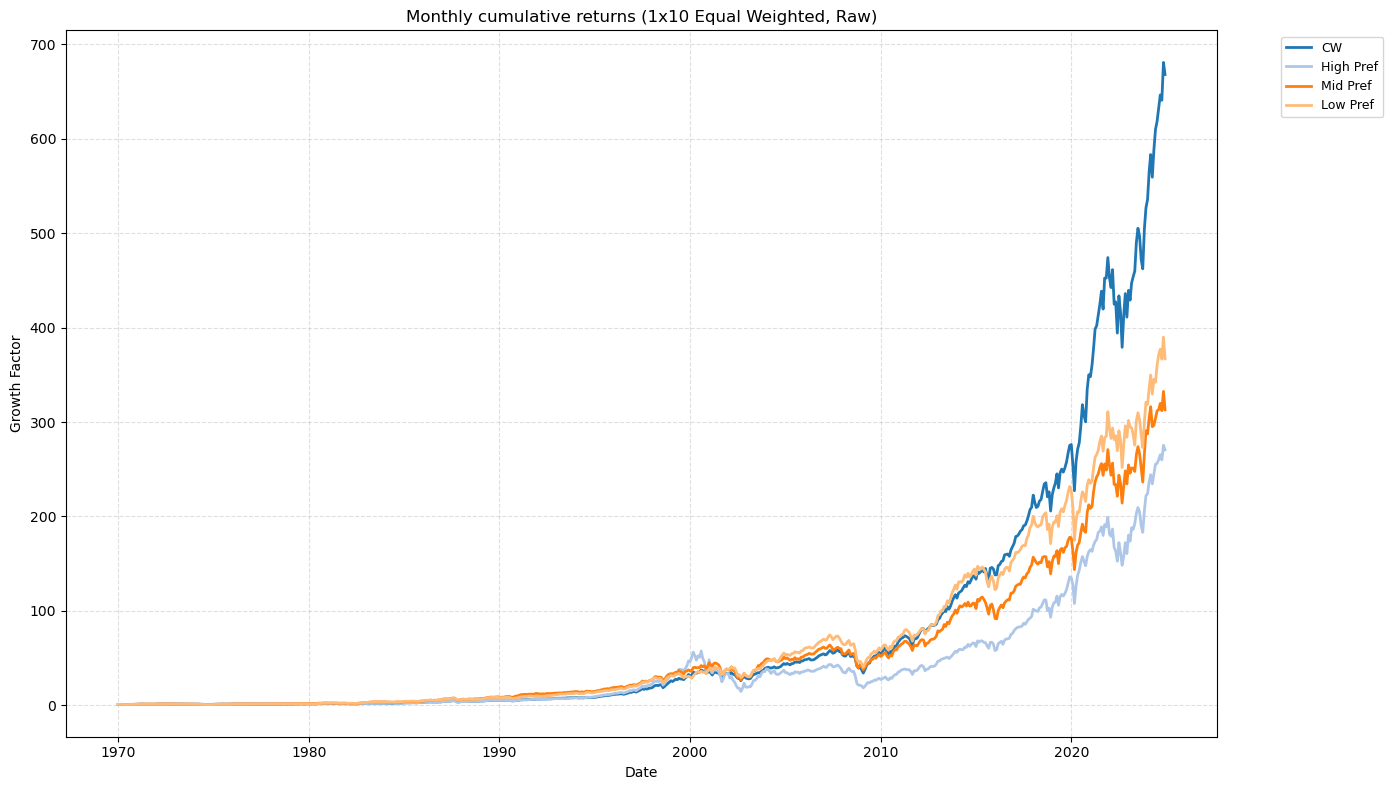

In [50]:
fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Monthly cumulative returns ({n_q1}x{n_q2} Equal Weighted, Raw)", log=False)

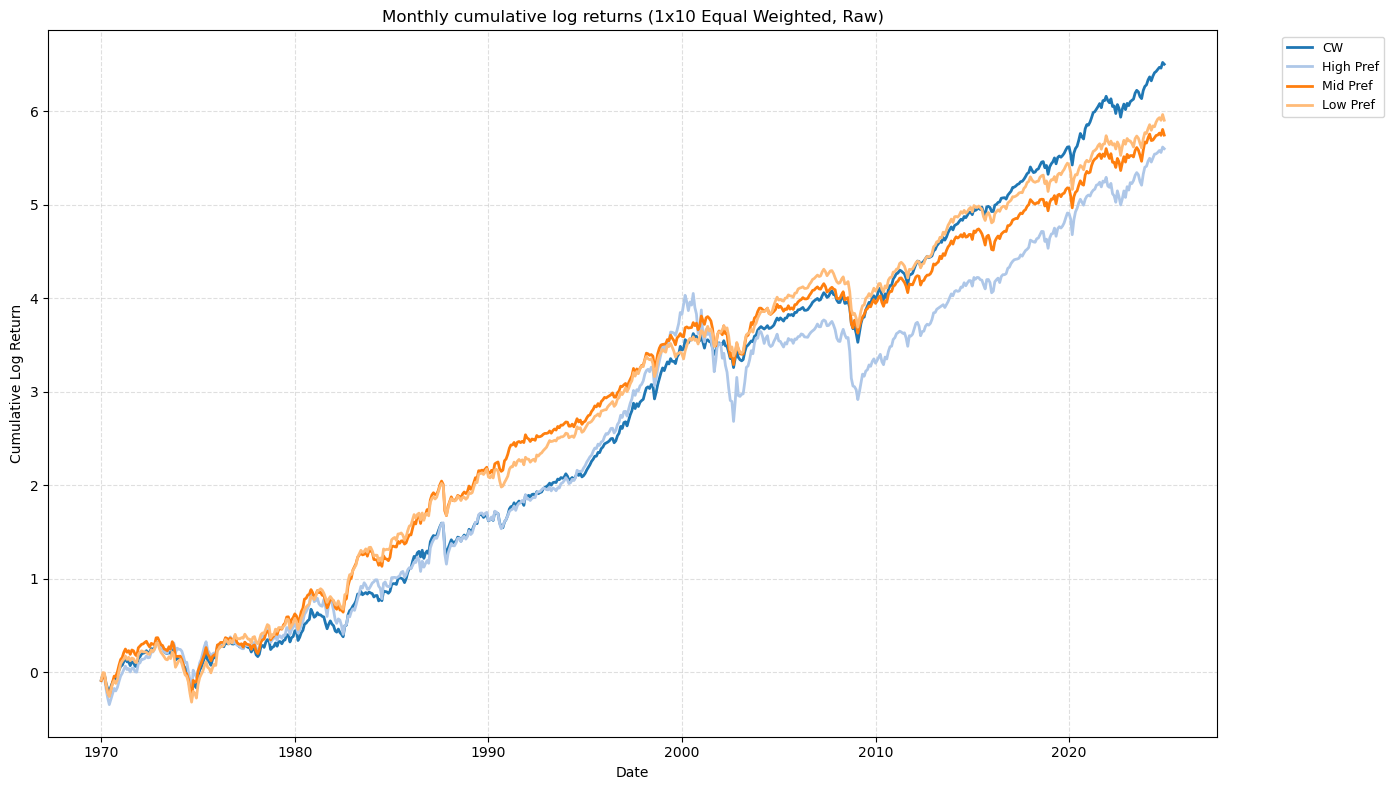

In [51]:
fmb_plots.plot_cum_returns(ew_complete_df[selected_columns],
                                title=f"Monthly cumulative log returns ({n_q1}x{n_q2} Equal Weighted, Raw)",log = True)

In [52]:
monthly_ew_quantile_returns = ew_complete_df[selected_columns]

In [53]:
monthly_ew_quantile_returns.to_csv(save_dir / f"monthly_{period}_ew_quantile_returns_{n_q1}x{n_q2}.csv")

In [54]:
# Arithmetic mean grid (annualized as mean × 12)
#fmb_plots.plot_mean_grid_new(ew_results["mean_grid"], annualize=True, frequency='monthly', cw=False, geometric=False)

In [55]:
ew_portrets_raw

,Q1_Q1,Q1_Q2,Q1_Q3,Q1_Q4,Q1_Q5,Q1_Q6,Q1_Q7,Q1_Q8,Q1_Q9,Q1_Q10
date,,,,,,,,,,
1970-01-01,-0.089284,-0.085726,-0.076823,-0.076155,-0.048576,-0.027255,-0.034047,-0.047865,-0.033196,-0.045049
1970-02-01,0.054963,0.046608,0.078285,0.079548,0.078727,0.059503,0.077758,0.067106,0.087910,0.108147
1970-03-01,-0.013290,0.014179,-0.004197,0.018182,-0.001503,0.025063,0.009514,0.007404,0.022142,0.012373
1970-04-01,-0.117362,-0.102198,-0.111624,-0.104517,-0.093738,-0.096713,-0.111403,-0.095520,-0.117617,-0.113354
1970-05-01,-0.091641,-0.068642,-0.086771,-0.071801,-0.052830,-0.074727,-0.073305,-0.065121,-0.076990,-0.100624
...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.015389,0.004416,0.032660,0.038405,0.028066,0.036679,0.021252,0.030826,0.037142,0.011544
2024-09-01,0.020375,0.021018,0.015121,0.034844,0.022846,0.024150,0.034945,0.027327,0.007680,-0.003673
2024-10-01,-0.020766,-0.023864,-0.027832,0.002792,-0.026773,0.008213,-0.003172,-0.021567,-0.009937,-0.046860


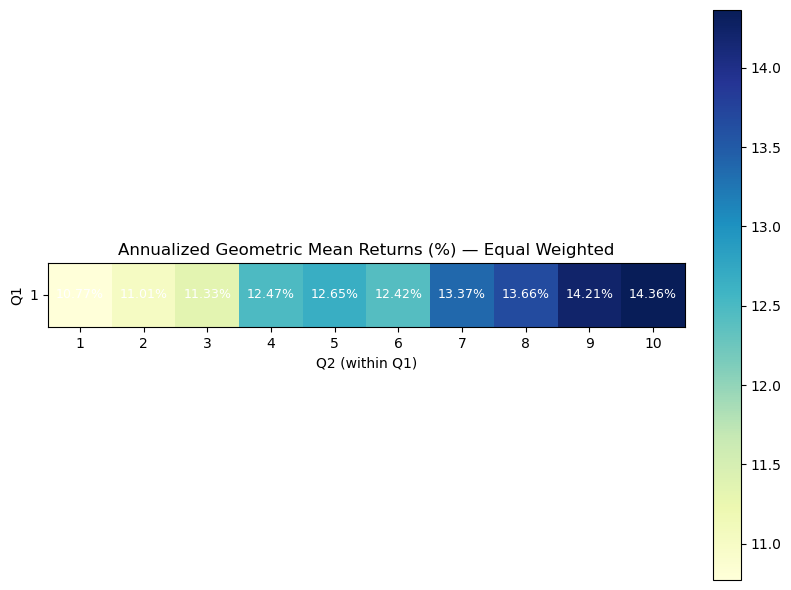

In [56]:
# True geometric mean grid (annualized as (1+geo_monthly)^12 − 1)
ew_actual_mean_grid = fmb_plots.plot_mean_grid_new(
    ew_results["mean_grid"], annualize=True, frequency='monthly', cw=False, geometric=True,
    portrets_wide=ew_portrets_raw
)

In [57]:
ew_actual_mean_grid

,1,2,3,4,5,6,7,8,9,10
1,10.770714,11.0132,11.334883,12.472605,12.654309,12.423749,13.370976,13.661563,14.211906,14.364942


In [58]:
# ── Benchmark: annualized geometric mean returns over the analysis period ──
cw_geo = np.expm1(np.log1p(cw_complete_df['CW']).mean())
cw_ann = (1 + cw_geo) ** 12 - 1
print(f"Annualized Geometric Mean Return ({start_date[:4]}–2024)")
print(f"  CW (ours) : {cw_ann:.2%}")
try:
    spy_geo = np.expm1(np.log1p(spy_ret.loc[start_date:]).mean())
    spy_ann = (1 + spy_geo) ** 12 - 1
    print(f"  SPY       : {spy_ann:.2%}")
except Exception:
    print("  SPY       : (run ETF cell first)")

Annualized Geometric Mean Return (1969–2024)
  CW (ours) : 12.55%
  SPY       : 10.45%


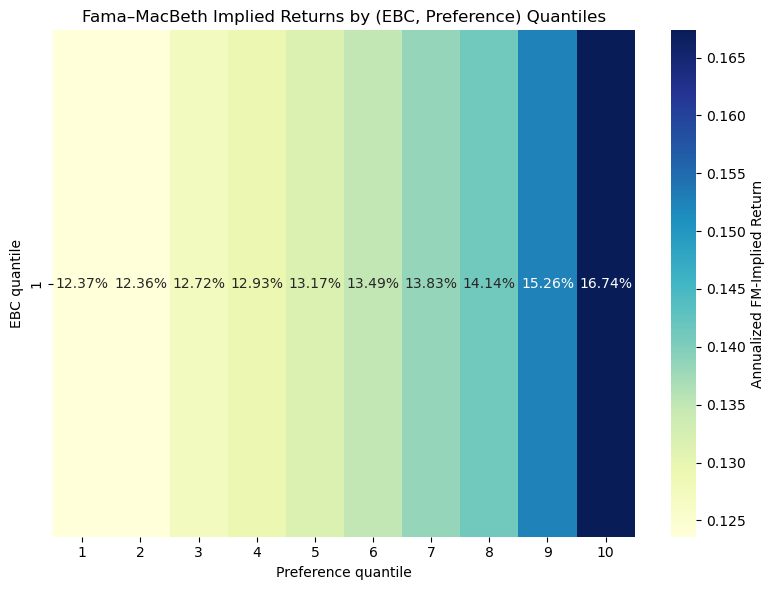

In [59]:
ew_implied_mean_grid = fmb_plots.plot_expected_return_grid(ew_results["pricing"], ew_results["fm_table"], n_q1, n_q2)

# <span style="color:red"> Transaction Costs — Quantile Portfolios </span>

**Formula (Invesco):** `TC = 2 × Turnover × 0.0005`

| Term | Meaning |
|---|---|
| `Turnover` | Fraction of holdings that *exit* a cell at each quarterly rebalancing |
| `0.0005` | One-way cost per dollar traded (5 bps: bid-ask spread + execution) |
| `× 2` | Round-trip: pay the spread to **sell** exiting stocks **and** to **buy** replacements |

Rebalancing is **quarterly**, so the cost is a one-time deduction applied in the **first month** of each new quarter. Non-rebalancing months are unaffected.

> To change the cost assumption, adjust `ONE_WAY_COST` below.

In [60]:
ONE_WAY_COST = 0.0005  # bps per side — change here to update everything below

# ── Step 1: EW turnover (from member assignments) ─────────────────────────
# Turnover is identical for EW and CW since they share the same beta sorts / membership
members_ew = ew_results["members"].copy()
m_ew = members_ew.reset_index()
m_ew['period'] = m_ew['date'].dt.to_period('Q')
first_date_per_period_ew = m_ew.groupby('period')['date'].min()
m_ew_first = m_ew[m_ew['date'].isin(first_date_per_period_ew.values)]

portfolio_names_ew = {
    (1,1): "EBC_High_Pref_High", (1,2): "EBC_High_Pref_Mid", (1,3): "EBC_High_Pref_Low",
    (2,1): "EBC_Mid_Pref_High",  (2,2): "EBC_Mid_Pref_Mid",  (2,3): "EBC_Mid_Pref_Low",
    (3,1): "EBC_Low_Pref_High",  (3,2): "EBC_Low_Pref_Mid",  (3,3): "EBC_Low_Pref_Low",
}

turnover_dict_ew = {}
for q1 in range(1, n_q1 + 1):
    for q2 in range(1, n_q2 + 1):
        cell_data = m_ew_first[(m_ew_first['q1'] == q1) & (m_ew_first['q2'] == q2)]
        by_period = cell_data.groupby('period')['ticker'].apply(set)
        turnovers, dates_out = [], []
        prev_set = None
        for period_key, tickers in by_period.items():
            if prev_set is not None:
                left = prev_set - tickers
                turnovers.append(len(left) / len(prev_set) if prev_set else np.nan)
                dates_out.append(period_key.to_timestamp())
            prev_set = tickers
        turnover_dict_ew[portfolio_names_ew[(q1, q2)]] = pd.Series(turnovers, index=dates_out)

turnover_ew = pd.DataFrame(turnover_dict_ew)
turnover_ew_q = turnover_ew.copy()
turnover_ew_q.index = pd.DatetimeIndex(turnover_ew_q.index).to_period('Q')

# ── Step 2: Helper — map quarterly TC to first monthly return of each quarter
def build_tc_monthly(gross_df, turnover_q_df, one_way_cost):
    monthly_quarters = gross_df.index.to_period('Q')
    first_month_of_quarter = {}
    for date, q in zip(gross_df.index, monthly_quarters):
        if q not in first_month_of_quarter:
            first_month_of_quarter[q] = date
    tc = pd.DataFrame(0.0, index=gross_df.index, columns=gross_df.columns)
    for col in turnover_q_df.columns:
        if col not in tc.columns:
            continue
        for q_period, to_val in turnover_q_df[col].items():
            if q_period in first_month_of_quarter and not np.isnan(to_val):
                tc.loc[first_month_of_quarter[q_period], col] = 2 * to_val * one_way_cost
    return tc

# ── Step 3: Apply TC to both EW and CW portfolios ─────────────────────────
ew_gross = ew_results['portrets_wide'].copy()   # already renamed to EBC_High_Pref_High etc.
cw_gross = cw_results['portrets_wide'].copy()

ew_tc = build_tc_monthly(ew_gross, turnover_ew_q, ONE_WAY_COST)
cw_tc = build_tc_monthly(cw_gross, turnover_ew_q, ONE_WAY_COST)

ew_net = ew_gross - ew_tc
cw_net = cw_gross - cw_tc

print(f"One-way cost : {ONE_WAY_COST*10_000:.1f} bps  |  Round-trip per 100% turnover: {2*ONE_WAY_COST*100:.2f}%")
print(f"\nMean quarterly TC per EW portfolio (bps):")
print((ew_tc[ew_tc > 0].mean() * 10_000).round(2).to_string())

KeyError: (1, 4)

In [61]:
# ── Gross vs Net side-by-side (log cumulative returns) ────────────────────
# Left  = Without fee (theoretical)  |  Right = With fee (practical)

palette = plt.cm.tab20.colors
bench_color = palette[0]
port_colors = palette[1:10]

port_cols = list(ew_gross.columns)

bench = cw_complete_df['CW'].dropna()
bench_logcum = np.log1p(bench).cumsum()

def plot_gross_net_side_by_side(gross_df, net_df, bench_logcum, suptitle):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    for ax, df, subtitle in zip(axes,
                                [gross_df, net_df],
                                ["Without Fee (Theoretical)", "With Fee (Practical)"]):
        ax.plot(bench_logcum.index, bench_logcum.values,
                color=bench_color, linewidth=2, label='CW')
        for col, color in zip(port_cols, port_colors):
            lc = np.log1p(df[col].dropna()).cumsum()
            ax.plot(lc.index, lc.values, color=color, linewidth=1.5, label=col)
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlabel("Date")
        ax.set_ylabel("Cumulative Log Return")
        ax.grid(True, linestyle='--', alpha=0.4)

    # Single shared legend to the right of both panels
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=1, fontsize=9,
               bbox_to_anchor=(1.0, 0.5), loc='center left')
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_gross_net_side_by_side(
    cw_gross, cw_net, bench_logcum,
    f"CW Quantile Portfolios — {period.replace('_','–')}  |  TC = 2 × Turnover × {ONE_WAY_COST}"
)

plot_gross_net_side_by_side(
    ew_gross, ew_net, bench_logcum,
    f"EW Quantile Portfolios — {period.replace('_','–')}  |  TC = 2 × Turnover × {ONE_WAY_COST}"
)

NameError: name 'ew_gross' is not defined

In [69]:
# ── Summary: Gross vs Net annualized geometric mean returns ───────────────
def tc_summary(gross_df, net_df, tc_df, label):
    rows = []
    for col in gross_df.columns:
        ann_gross = (1 + np.expm1(np.log1p(gross_df[col].dropna()).mean())) ** 12 - 1
        ann_net   = (1 + np.expm1(np.log1p(net_df[col].dropna()).mean())) ** 12 - 1
        avg_ann_tc = tc_df[col][tc_df[col] > 0].mean() * 4  # 4 quarters/year
        rows.append({
            "Portfolio": col.replace("EBC_", "").replace("_", " "),
            "Gross Ann.": f"{ann_gross:.2%}",
            "Net Ann.":   f"{ann_net:.2%}",
            "TC Drag (bps)": f"{(ann_gross - ann_net)*10_000:.1f}",
            "Avg Ann. TC (bps)": f"{avg_ann_tc*10_000:.1f}",
        })
    df = pd.DataFrame(rows).set_index("Portfolio")
    print(f"\n{'─'*60}")
    print(f"  {label}  |  {ONE_WAY_COST*10_000:.0f}bps/side  |  Formula: 2 × Turnover × {ONE_WAY_COST}")
    print(f"{'─'*60}")
    display(df)

tc_summary(ew_gross, ew_net, ew_tc, "EW Quantile Portfolios")
tc_summary(cw_gross, cw_net, cw_tc, "CW Quantile Portfolios")


────────────────────────────────────────────────────────────
  EW Quantile Portfolios  |  5bps/side  |  Formula: 2 × Turnover × 0.0005
────────────────────────────────────────────────────────────


,Gross Ann.,Net Ann.,TC Drag (bps),Avg Ann. TC (bps)
Portfolio,,,,
High Pref,11.21%,11.21%,0.0,nan
Mid Pref,12.91%,12.91%,0.0,nan
Low Pref,13.97%,13.97%,0.0,nan



────────────────────────────────────────────────────────────
  CW Quantile Portfolios  |  5bps/side  |  Formula: 2 × Turnover × 0.0005
────────────────────────────────────────────────────────────


,Gross Ann.,Net Ann.,TC Drag (bps),Avg Ann. TC (bps)
Portfolio,,,,
High Pref,10.59%,10.59%,0.0,nan
Mid Pref,11.47%,11.47%,0.0,nan
Low Pref,13.10%,13.10%,0.0,nan


# <span style="color:red"> Fitted GARCH </span>

In [70]:
from arch import arch_model

In [71]:
def fit_garch_model(returns):
    """
    Fit GARCH(1,1) with student t errors
    """

    returns = returns.dropna()

    # Scale to percentage
    returns_scaled = returns * 100

    am = arch_model(
        returns_scaled,
        mean="Constant",
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    res = am.fit(disp="off")

    return res


In [72]:
cw_complete_df.columns

Index(['CW', 'EW', 'EBC', 'MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'MOM',
       'CW_RF', 'EW_RF', 'EBC_RF', 'CW-EW', 'CW-EBC', 'MKT', 'High Pref',
       'Mid Pref', 'Low Pref'],
      dtype='object')

In [73]:
portfolio_name = 'CW'
portfolio = cw_complete_df[portfolio_name]

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                           CW   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1874.02
Distribution:      Standardized Student's t   AIC:                           3758.05
Method:                  Maximum Likelihood   BIC:                           3780.49
                                              No. Observations:                  658
Date:                      Thu, Apr 02 2026   Df Residuals:                      657
Time:                              08:46:50   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             1

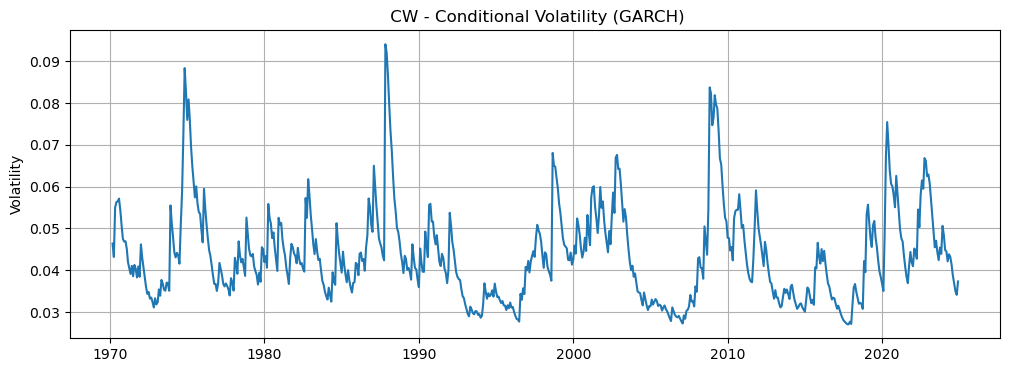

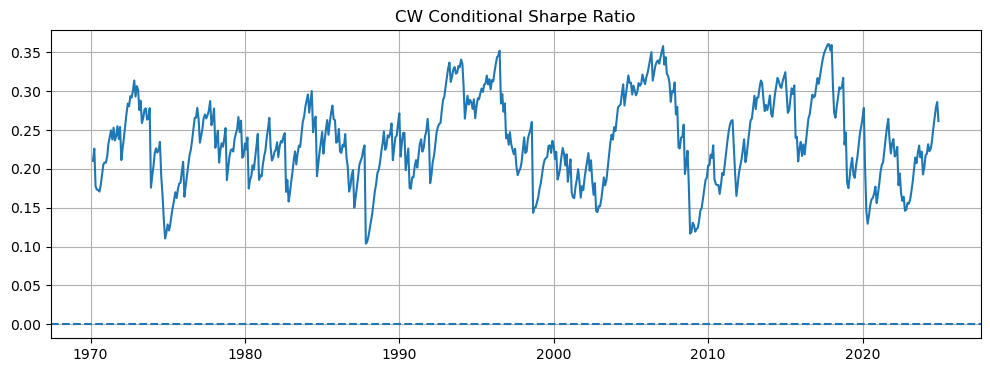

In [74]:
garch_res = fit_garch_model(portfolio)

print(garch_res.summary())


cond_vol = garch_res.conditional_volatility / 100  # scale back

plt.figure(figsize=(12,4))
plt.plot(cond_vol)
plt.title(f" {portfolio_name} - Conditional Volatility (GARCH)")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

mean_return = portfolio.mean()

cond_sharpe = mean_return / cond_vol

plt.figure(figsize=(12,4))
plt.plot(cond_sharpe)
plt.axhline(0, linestyle="--")
plt.title(f"{portfolio_name} Conditional Sharpe Ratio")
plt.grid(True)
plt.show()